In [273]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np


(500, 2)


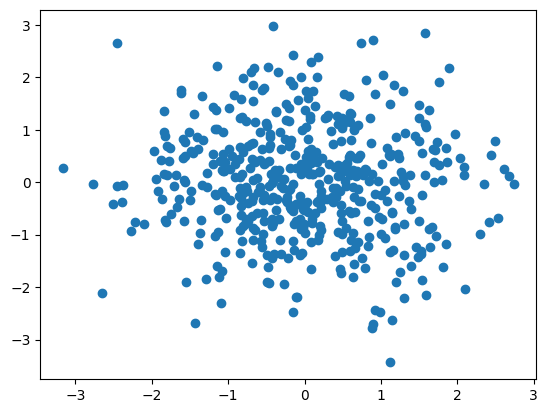

In [274]:
# ex 1
X, y = make_blobs(n_samples=500, centers=[[0, 0]], cluster_std=[[1, 1]])
print(X.shape)
plt.scatter(X[:, 0], X[:, 1])

In [275]:
proj_vectors = np.random.multivariate_normal(mean=(0, 0), cov=np.identity(2), size=5)
proj_vectors = proj_vectors / np.linalg.norm(proj_vectors, axis=1, keepdims=True)
print(proj_vectors)

[[-0.14395225  0.98958463]
 [ 0.99972837 -0.02330633]
 [-0.92023656  0.39136258]
 [ 0.72890361  0.68461634]
 [-0.22504705  0.9743479 ]]


In [276]:
probs = []
for vector in proj_vectors:
    proj = X @ vector
    hist, bin_edges = np.histogram(proj, range=[np.min(proj) - 1, np.max(proj) + 1])
   
    probs = hist / 500
    # plt.hist(proj)
    # plt.show()
probs = np.array(probs)
print(probs)
mean_probs = np.mean(probs, axis=0)
print(mean_probs)


[0.    0.004 0.03  0.116 0.256 0.332 0.18  0.068 0.014 0.   ]
0.1


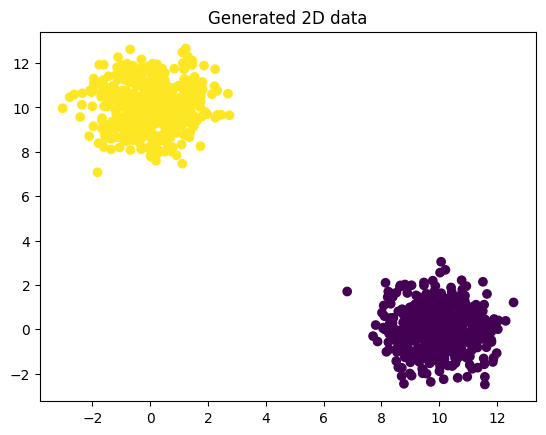

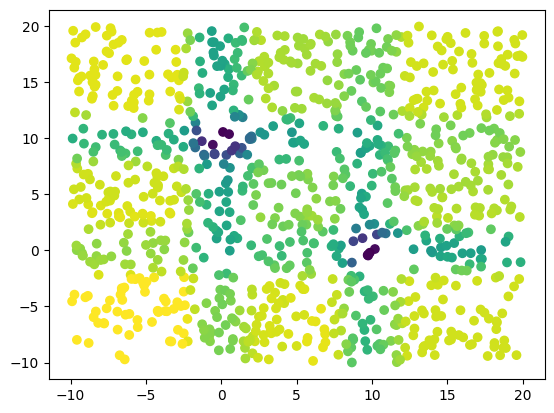

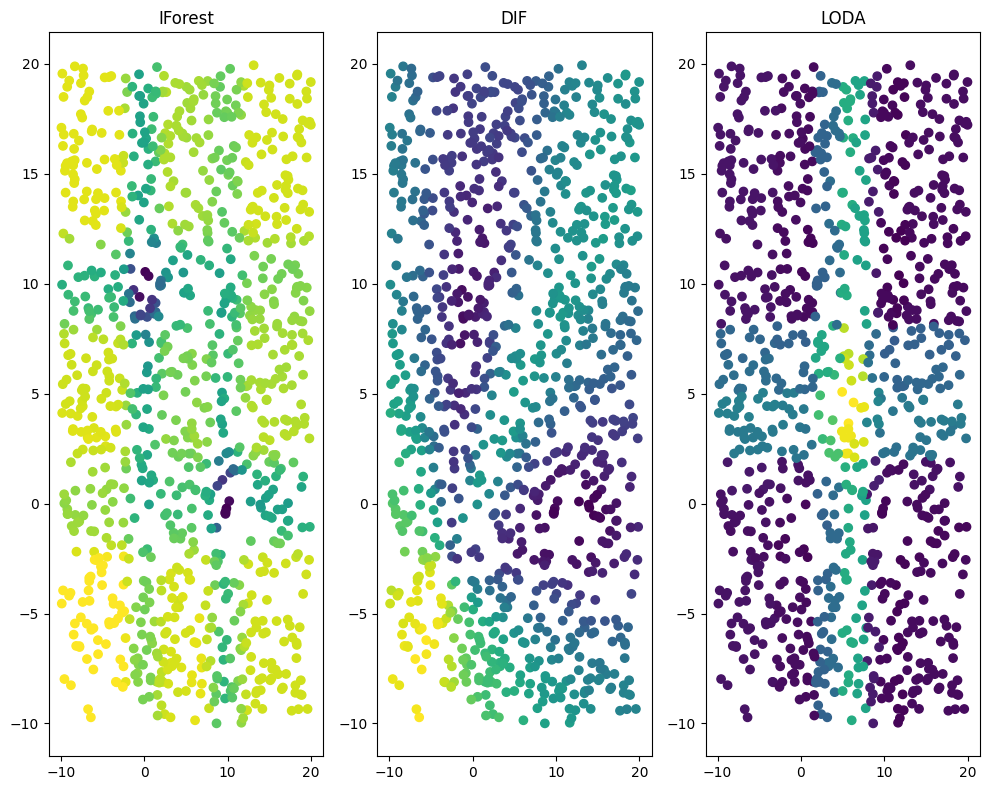

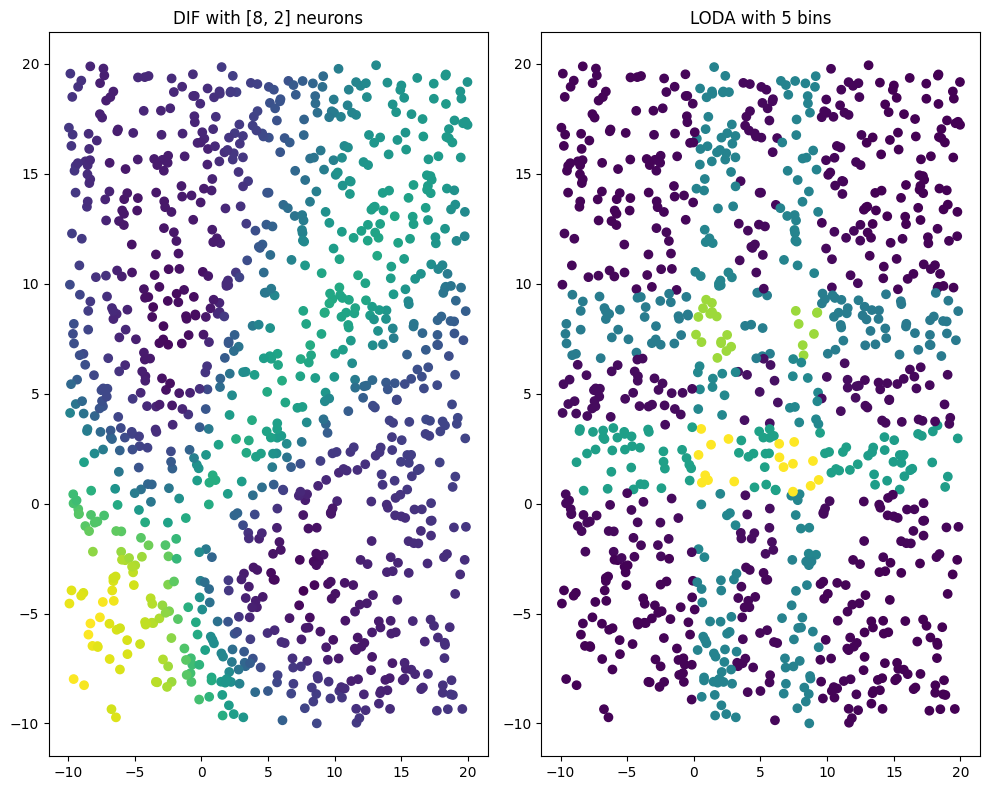

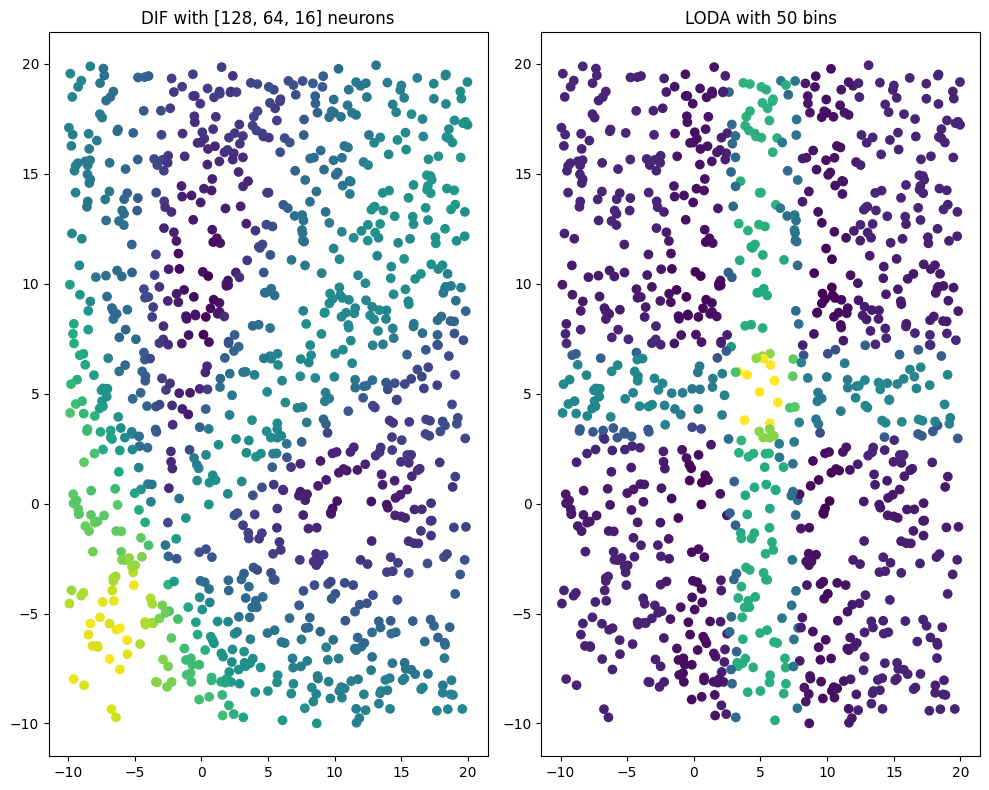

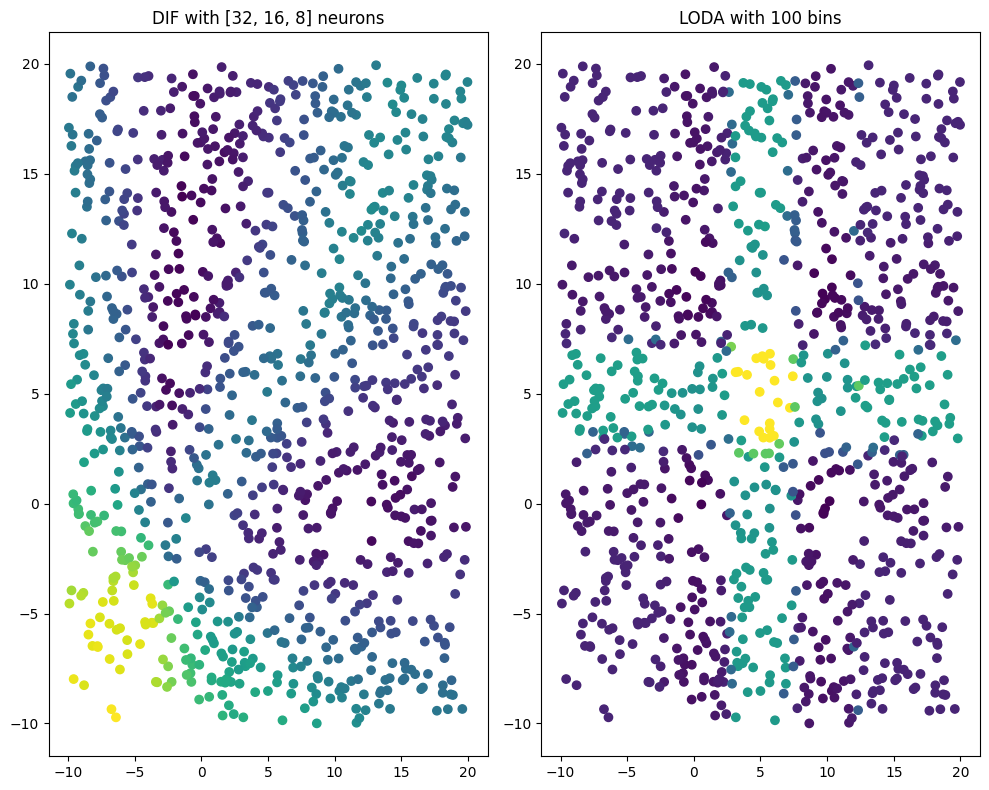

In [277]:
# ex 2
X, y = make_blobs(n_samples=[500, 500], centers=[[10, 0], [0, 10]], cluster_std=1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Generated 2D data')
plt.show()
from pyod.models.iforest import IForest

model = IForest(contamination=0.02)

model.fit(X)
test_data = np.random.uniform(low=-10, high=20, size=(1000, 2))
test_data.shape
iforest_scores = model.decision_function(test_data)

plt.scatter(test_data[:, 0], test_data[:, 1], c=iforest_scores)
plt.show()
from pyod.models.dif import DIF
from pyod.models.loda import LODA

dif = DIF(contamination=0.02)
loda = LODA(contamination=0.02)

dif.fit(X)
loda.fit(X)

dif_scores = dif.decision_function(test_data)
loda_scores = loda.decision_function(test_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 8))

axes[0].scatter(test_data[:, 0], test_data[:, 1], c=iforest_scores)
axes[0].set_title('IForest')

axes[1].scatter(test_data[:, 0], test_data[:, 1], c=dif_scores)
axes[1].set_title('DIF')

axes[2].scatter(test_data[:, 0], test_data[:, 1], c=loda_scores)
axes[2].set_title('LODA')

plt.tight_layout()
plt.show()

dif_hidden_neurons = [[8, 2], [128, 64, 16], [32, 16, 8]]
loda_n_bins = [5, 50, 100]
for i in range(3): 
    dif = DIF(contamination=0.02, hidden_neurons=dif_hidden_neurons[i])
    loda = LODA(contamination=0.02, n_bins=loda_n_bins[i])

    dif.fit(X)
    loda.fit(X)

    dif_scores = dif.decision_function(test_data)
    loda_scores = loda.decision_function(test_data)

    fig, axes = plt.subplots(1, 2, figsize=(10, 8))



    axes[0].scatter(test_data[:, 0], test_data[:, 1], c=dif_scores)
    axes[0].set_title(f'DIF with {dif_hidden_neurons[i]} neurons')

    axes[1].scatter(test_data[:, 0], test_data[:, 1], c=loda_scores)
    axes[1].set_title(f'LODA with {loda_n_bins[i]} bins')
    plt.tight_layout()
    plt.show()

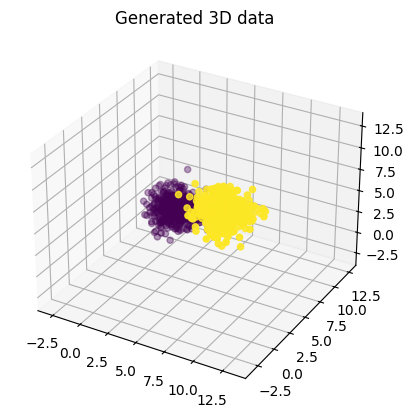

(1000, 3)


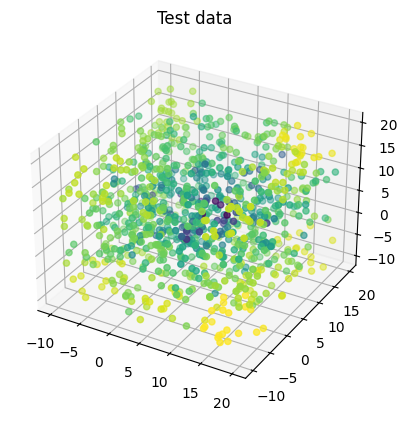

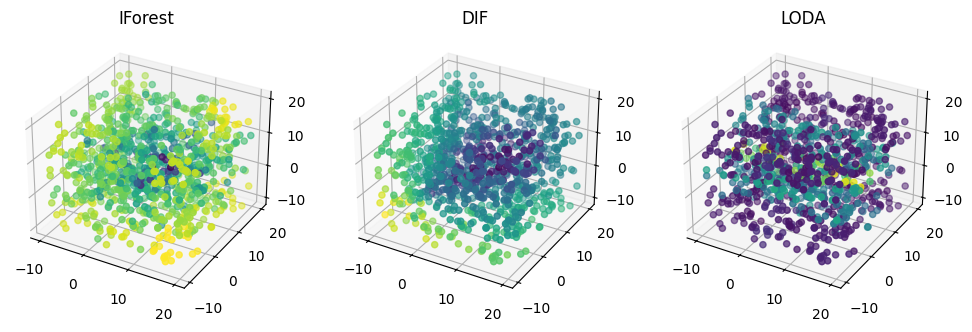

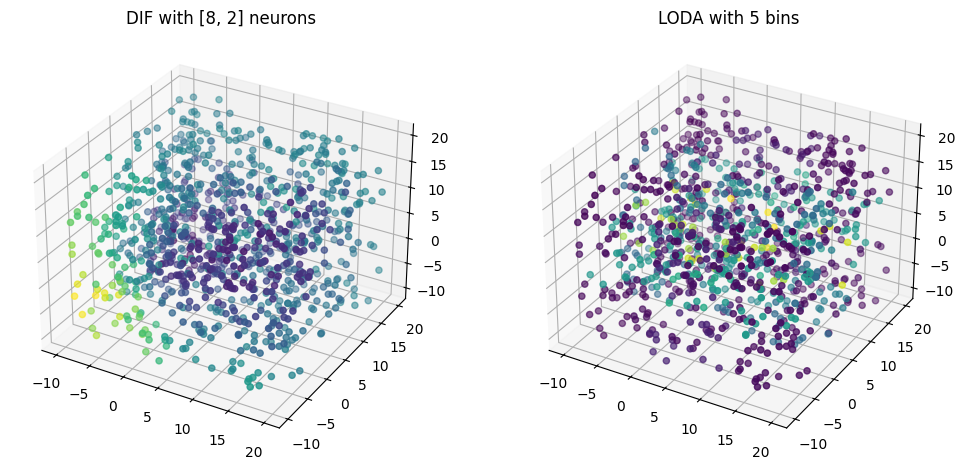

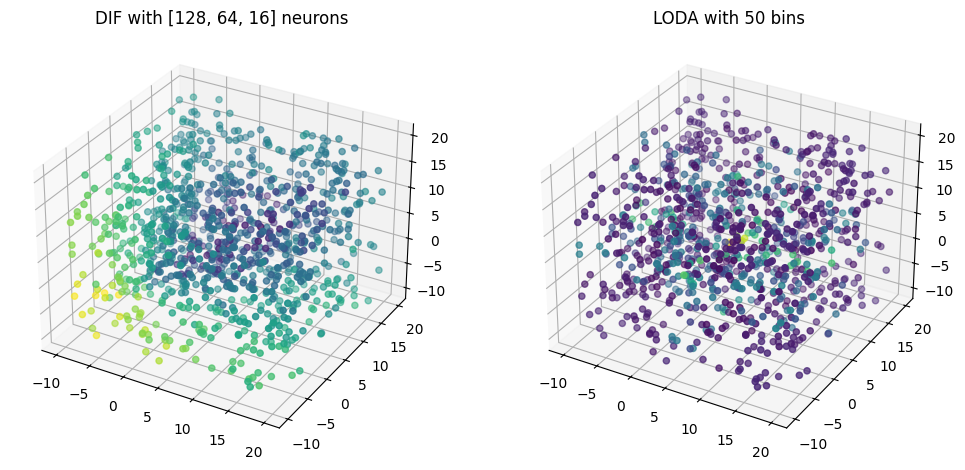

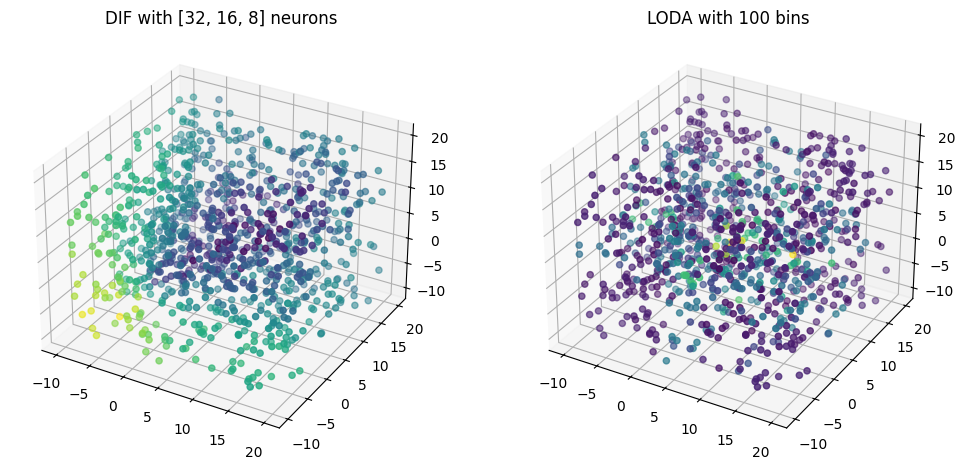

In [278]:
# 6. Redo all the steps in 3D (use (0, 10, 0) and (10, 0 , 10) as centers for
# the two clusters).
import warnings
warnings.filterwarnings("ignore", message=".*pin_memory.*")
# generate 2 clusters of 2D data
X, y = make_blobs(n_samples=[500, 500], centers=[[0, 10, 0], [10, 0, 10]], cluster_std=1)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y)
ax.set_title('Generated 3D data')
plt.show()

# fit IForest model
model = IForest(contamination=0.02)

model.fit(X)
# generate test data
test_data = np.random.uniform(low=-10, high=20, size=(1000, 3))
print(test_data.shape)

# plot the anomaly scores
iforest_scores = model.decision_function(test_data)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:, 2], c=iforest_scores)
ax.set_title('Test data')
plt.show()

# repeat procedure for DIF and LODA
dif = DIF(contamination=0.02)
loda = LODA(contamination=0.02)

dif.fit(X)
loda.fit(X)

# plot anomaly scores
dif_scores = dif.decision_function(test_data)
loda_scores = loda.decision_function(test_data)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(131, projection='3d')

ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:, 2], c=iforest_scores)
ax.set_title('IForest')

ax = fig.add_subplot(132, projection='3d')
ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:, 2], c=dif_scores)
ax.set_title('DIF')


ax = fig.add_subplot(133, projection='3d')
ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:, 2], c=loda_scores)
ax.set_title('LODA')

plt.show()

# try with diff number of neurons for DIF and bins for LODA
dif_hidden_neurons = [[8, 2], [128, 64, 16], [32, 16, 8]]
loda_n_bins = [5, 50, 100]
for i in range(3): 
    dif = DIF(contamination=0.02, hidden_neurons=dif_hidden_neurons[i])
    loda = LODA(contamination=0.02, n_bins=loda_n_bins[i])

    dif.fit(X)
    loda.fit(X)

    dif_scores = dif.decision_function(test_data)
    loda_scores = loda.decision_function(test_data)

        
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(121, projection='3d')  

    ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:, 2], c=dif_scores)
    ax.set_title(f'DIF with {dif_hidden_neurons[i]} neurons')

    ax = fig.add_subplot(122, projection='3d')  
    ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:, 2], c=loda_scores)
    ax.set_title(f'LODA with {loda_n_bins[i]} bins')
    plt.show()


In [279]:
# ex 3
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from pyod.utils.utility import standardizer
from sklearn.metrics import roc_auc_score, balanced_accuracy_score


shuttle =  loadmat('shuttle.mat')
X, y = shuttle['X'], shuttle['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_normalized, X_test_normalized = standardizer(X_train, X_test)

cont_rate = np.sum(y_train == 1) / len(X_train)
print(cont_rate)
iforest = IForest(contamination=cont_rate)
dif = DIF(contamination=cont_rate)
loda = LODA(contamination=cont_rate)

iforest.fit(X_normalized)
print("Finished iforest fitting")
dif.fit(X_normalized)
print("Finished dif fitting")
loda.fit(X_normalized)
print("Finished loda fitting")
iforest_preds_cont = iforest.decision_function(X_test_normalized)
dif_preds_cont = dif.decision_function(X_test_normalized)
loda_preds_cont = loda.decision_function(X_test_normalized)

iforest_preds_binary = iforest.predict(X_test_normalized)
dif_preds_binary = dif.predict(X_test_normalized)
loda_preds_binary = loda.predict(X_test_normalized)
iforest_roc_auc_score = roc_auc_score(y_test, iforest_preds_cont)
dif_roc_auc_score = roc_auc_score(y_test, dif_preds_cont)
loda_roc_auc_score = roc_auc_score(y_test, loda_preds_cont)

print("IFOREST_ROC_AUC:", iforest_roc_auc_score)
print("DIF_ROC_AUC:", dif_roc_auc_score)
print("LODA_ROC_AUC:", loda_roc_auc_score)

iforest_bac = balanced_accuracy_score(y_test, iforest_preds_binary)
dif_bac = balanced_accuracy_score(y_test, dif_preds_binary)
loda_bac = balanced_accuracy_score(y_test, loda_preds_binary)

print("IFOREST_BAC:",iforest_bac)
print("DIF_BAC:",dif_bac)
print("LODA_BAC:",loda_bac)

0.07172924163215426
Finished iforest fitting
Finished dif fitting
Finished loda fitting
IFOREST_ROC_AUC: 0.9973525266815885
DIF_ROC_AUC: 0.9674314077634381
LODA_ROC_AUC: 0.732409848931713
IFOREST_BAC: 0.9675984409659292
DIF_BAC: 0.5083644047637814
LODA_BAC: 0.7174970328519154


In [280]:
iforest_aucs = []
iforest_bacs = []
dif_aucs = []
dif_bacs = []
loda_aucs = []
loda_bacs = []

splits = 10
print(f"Starting evaluation for {splits} different train-test splits...")

for i in range(splits):
    print(f"Starting split {i}...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=i)
    X_normalized, X_test_normalized = standardizer(X_train, X_test)

    cont_rate = np.sum(y_train == 1) / len(X_train)
    print(cont_rate)
    iforest = IForest(contamination=cont_rate)
    dif = DIF(contamination=cont_rate)
    loda = LODA(contamination=cont_rate)

    iforest.fit(X_normalized)
    print("Finished iforest fitting")
    dif.fit(X_normalized)
    print("Finished dif fitting")
    loda.fit(X_normalized)
    print("Finished loda fitting")\
        
    iforest_preds_cont = iforest.decision_function(X_test_normalized)
    dif_preds_cont = dif.decision_function(X_test_normalized)
    loda_preds_cont = loda.decision_function(X_test_normalized)
    
    iforest_preds_binary = iforest.predict(X_test_normalized)
    dif_preds_binary = dif.predict(X_test_normalized)
    loda_preds_binary = loda.predict(X_test_normalized)
    
    iforest_aucs.append(roc_auc_score(y_test, iforest_preds_cont))
    dif_aucs.append(roc_auc_score(y_test, dif_preds_cont))
    loda_aucs.append(roc_auc_score(y_test, loda_preds_cont))

    iforest_bacs.append(balanced_accuracy_score(y_test, iforest_preds_binary))
    dif_bacs.append(balanced_accuracy_score(y_test, dif_preds_binary))
    loda_bacs.append(balanced_accuracy_score(y_test, loda_preds_binary))


print("IFOREST_MEAN_AUC", np.mean(np.array(iforest_aucs)))

print("DIF_MEAN_AUC:",np.mean(np.array(dif_aucs)))

print("LODA_MEAN_AUC", np.mean(np.array(loda_aucs)))


print("IFOREST_MEAN_BAC", np.mean(np.array(iforest_bacs)))

print("DIF_MEAN_BAC", np.mean(np.array(dif_bacs)))

print("LODA_MEAN_BAC", np.mean(np.array(loda_bacs)))

Starting evaluation for 10 different train-test splits...
Starting split 0...
0.07050716274017245
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 1...
0.0714237219091588
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 2...
0.07234028107814515
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 3...
0.07105030891438659
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 4...
0.07071084255550275
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 5...
0.07257790752936384
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 6...
0.07152556181682396
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 7...
0.07179713490393103
Finished iforest fitting
Finished dif fitting
Finished loda fitting
Starting split 8...
0.0710163622784982
Finished iforest fitting
Finished dif fi